<a href="https://colab.research.google.com/github/OlenaBogoliubova/DATA-LOVE-ACADEMY/blob/main/HW_%D0%90%D0%BB%D0%B3%D0%BE%D1%80%D0%B8%D1%82%D0%BC%D0%B8_%D0%BA%D0%BB%D0%B0%D1%81%D1%82%D0%B5%D1%80%D0%B8%D0%B7%D0%B0%D1%86%D1%96%D1%97_Bogoliubova.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Домашнє завдання: Кластеризація в Аналізі Персоналій Клієнтів

#### Контекст
В цьому ДЗ ми скористаємось алгоритмами кластеризації для задачі аналізу портретів клієнтів (Customer Personality Analysis).

Customer Personality Analysis - це аналіз різних сегментів клієнтів компанії. Цей аналіз дозволяє бізнесу краще розуміти своїх клієнтів і полегшує процес адаптації продуктів під конкретні потреби, поведінку та інтереси різних типів клієнтів.

Аналіз портретів клієнтів допомагає бізнесу змінювати свій продукт на основі цільової аудиторії, розділеної на різні сегменти. Наприклад, замість того, щоб витрачати гроші на маркетинг нового продукту для всіх клієнтів у базі даних компанії, бізнес може проаналізувати, який сегмент клієнтів найімовірніше придбає продукт, і потім зосередити маркетингові зусилля лише на цьому сегменті.

#### Завдання
На основі наданих даних в файлі `marketing_campaign.csv` потрібно виконати кластеризацію, щоб виявити сегменти клієнтів.

#### Вхідні дані
Вам надано набір даних з такими атрибутами:

**Характеристики користувачів:**
- `ID`: Унікальний ідентифікатор клієнта
- `Year_Birth`: Рік народження клієнта
- `Education`: Рівень освіти клієнта
- `Marital_Status`: Сімейний стан клієнта
- `Income`: Річний дохід домогосподарства клієнта
- `Kidhome`: Кількість дітей у домогосподарстві клієнта
- `Teenhome`: Кількість підлітків у домогосподарстві клієнта
- `Dt_Customer`: Дата реєстрації клієнта у компанії
- `Recency`: Кількість днів з моменту останньої покупки клієнта
- `Complain`: 1, якщо клієнт скаржився за останні 2 роки, 0 - якщо ні

**Продукти:**
- `MntWines`: Сума, витрачена на вино за останні 2 роки
- `MntFruits`: Сума, витрачена на фрукти за останні 2 роки
- `MntMeatProducts`: Сума, витрачена на м'ясні продукти за останні 2 роки
- `MntFishProducts`: Сума, витрачена на рибні продукти за останні 2 роки
- `MntSweetProducts`: Сума, витрачена на солодощі за останні 2 роки
- `MntGoldProds`: Сума, витрачена на золото за останні 2 роки

**Акції:**
- `NumDealsPurchases`: Кількість покупок, зроблених з використанням знижок
- `AcceptedCmp1`: 1, якщо клієнт прийняв пропозицію у першій кампанії, 0 - якщо ні
- `AcceptedCmp2`: 1, якщо клієнт прийняв пропозицію у другій кампанії, 0 - якщо ні
- `AcceptedCmp3`: 1, якщо клієнт прийняв пропозицію у третій кампанії, 0 - якщо ні
- `AcceptedCmp4`: 1, якщо клієнт прийняв пропозицію у четвертій кампанії, 0 - якщо ні
- `AcceptedCmp5`: 1, якщо клієнт прийняв пропозицію у п'ятій кампанії, 0 - якщо ні
- `Response`: 1, якщо клієнт прийняв пропозицію в останній кампанії, 0 - якщо ні

**Взаємодія з компанією:**
- `NumWebPurchases`: Кількість покупок, зроблених через вебсайт компанії
- `NumCatalogPurchases`: Кількість покупок, зроблених за каталогом
- `NumStorePurchases`: Кількість покупок, зроблених безпосередньо у магазинах
- `NumWebVisitsMonth`: Кількість відвідувань вебсайту компанії за останній місяць


**Завдання 1**. Завантажте дані з `marketing_campaign.csv` в Pandas dataframe і виведіть основну інформацію про дані: скільки всього рядків і колонок, які типи даних мають колонки, скільки пропущених значень.

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
from datetime import datetime
from sklearn.cluster import KMeans
import plotly.express as px
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.cluster import AgglomerativeClustering


In [26]:
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/DATA LOVE/marketing_campaign.csv', sep='\t')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [27]:
# Розмір даних: кількість рядків і колонок
print(f"Кількість рядків: {df.shape[0]}")
print(f"Кількість колонок: {df.shape[1]}")

# Основна інформація: типи даних, non-null count
df.head()
df.info()
df.describe()

# Пропущені значення по кожній колонці
missing = df.isnull().sum()
missing = missing[missing > 0]
print(missing if len(missing) > 0 else "Пропущених значень немає")

Кількість рядків: 2240
Кількість колонок: 29
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64 

**Завдання 2.** Заповніть пропущені значення з врахуванням того завдання (кластеризація), яке ми виконуємо. Поясніть свій вибір заповнення пропущених значень.

In [30]:
# Перевіримо розподіл Income перед заповненням
print(df['Income'].describe())
print(f"\nПропусків: {df['Income'].isnull().sum()}")

# Перевіримо, чи є зв'язок Income з Education (для обґрунтованого заповнення)
print(df.groupby('Education')['Income'].median())

# Заповнення пропусків медіаною Income в межах групи Education
# (а не глобальною медіаною/середнім по всьому датасету)
df['Income'] = df.groupby('Education')['Income'].transform(
    lambda x: x.fillna(x.median()))

print(f"Пропусків залишилось: {df['Income'].isnull().sum()}")
print(df['Income'].describe())

count      2240.000000
mean      52242.594866
std       25039.061738
min        1730.000000
25%       35538.750000
50%       51498.500000
75%       68289.750000
max      666666.000000
Name: Income, dtype: float64

Пропусків: 0
Education
2n Cycle      46805.0
Basic         20744.0
Graduation    52028.5
Master        50943.0
PhD           55212.0
Name: Income, dtype: float64
Пропусків залишилось: 0
count      2240.000000
mean      52242.594866
std       25039.061738
min        1730.000000
25%       35538.750000
50%       51498.500000
75%       68289.750000
max      666666.000000
Name: Income, dtype: float64


In [31]:
# Missing values ​​and duplicates
print("NaN:")
print(df.isnull().sum())

print("\nDublicates:", df.duplicated().sum())

NaN:
ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
AcceptedCmp3           0
AcceptedCmp4           0
AcceptedCmp5           0
AcceptedCmp1           0
AcceptedCmp2           0
Complain               0
Z_CostContact          0
Z_Revenue              0
Response               0
dtype: int64

Dublicates: 0


In [32]:
print(df['Income'].describe())
print(f"\nПропусків: {df['Income'].isnull().sum()}")

count      2240.000000
mean      52242.594866
std       25039.061738
min        1730.000000
25%       35538.750000
50%       51498.500000
75%       68289.750000
max      666666.000000
Name: Income, dtype: float64

Пропусків: 0


24 пропуски — це лише ~1% даних, але для кластеризації важливий кожен клієнт, і видалення рядків без потреби зменшує вибірку та може випадково прибрати цілий сегмент клієнтів.

З describe() видно, що Income має відчутні викиди (max суттєво більший за 75-й перцентиль) і правосторонню асиметрію. Середнє чутливе до викидів і завищить заповнені значення, тоді як медіана — робастна оцінка "типового" доходу.

Для кластеризації важливо, щоб заповнені значення не спотворювали природну варіативність між сегментами. З таблиці видно, що дохід суттєво відрізняється залежно від рівня освіти (наприклад, Basic ≈ 20 744, а PhD ≈ 55 212). Якби ми заповнили всі пропуски однією глобальною медіаною (~51 700), клієнти з базовою освітою отримали б штучно завищений дохід, що спотворило б їхній профіль і могло призвести до неправильного віднесення до кластера. Групове заповнення зберігає реалістичний зв'язок між ознаками, який важливий для якісної сегментації.

**Завдання 3.** У нас є декілька колонок з категоріальними значеннями та одна колонка з датою. Як би ви обробили ці колонки для того, аби передати їх в алгоритм кластеризації?

Реалізуйте обробку категоріальних колонок і колонки з датою та перетворіть їх на ознаки, корисні для кластеризації з вашого погляду.

In [33]:
# Унікальні значення категоріальних колонок
print(df['Education'].value_counts())
print(df['Marital_Status'].value_counts())

Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64
Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64


Обґрунтування підходу

1. Education — порядкова змінна. Рівні освіти мають природний порядок за "рівнем" (Basic → 2n Cycle → Graduation → Master → PhD), тому можна закодувати їх числами 0–4, а не one-hot. Це зберігає інформацію про відстань між рівнями, що корисно для алгоритмів кластеризації, які працюють з евклідовою відстанню (K-Means).

2. Marital_Status — номінальна змінна, але потребує чистки. Значення Absurd, YOLO, Alone — це, по суті, шум/помилки введення (по 2-3 записи), семантично близькі до "Single". Замість one-hot з купою рідкісних категорій, можна створити змістовну бінарну ознаку Is_Partner (чи живе клієнт у парі — Married/Together = 1, решта = 0).
Це напряму пов'язано із задачею — сімейний стан впливає на споживчу поведінку, а бінарна ознака стабільніша за розріджений one-hot із категоріями-аномаліями.

3. Dt_Customer — дата реєстрації. Сама дата не несе сенсу для кластеризації, але важливий "стаж" клієнта — скільки днів він є клієнтом компанії відносно останньої дати реєстрації в датасеті. Це перетворює дату на змістовну числову ознаку Customer_For.



In [34]:
# 1. Education: ordinal encoding
education_order = {
    'Basic': 0,
    '2n Cycle': 1,
    'Graduation': 2,
    'Master': 3,
    'PhD': 4
}
df['Education_Level'] = df['Education'].map(education_order)

# 2. Marital_Status: бінарна ознака "живе в парі"
partner_statuses = ['Married', 'Together']
df['Is_Partner'] = df['Marital_Status'].apply(lambda x: 1 if x in partner_statuses else 0)

# 3. Dt_Customer: перетворення на "стаж клієнта" у днях
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], format='%d-%m-%Y')

# Точка відліку - найпізніша дата реєстрації в датасеті
# (імітує "сьогодні" на момент збору даних)
reference_date = df['Dt_Customer'].max()
df['Customer_For'] = (reference_date - df['Dt_Customer']).dt.days

print(df[['Education', 'Education_Level', 'Marital_Status', 'Is_Partner',
          'Dt_Customer', 'Customer_For']].head(10))

print(df['Customer_For'].describe())

# Видаляємо оригінальні текстові/датові колонки - вони більше не потрібні
df.drop(columns=['Education', 'Marital_Status', 'Dt_Customer'], inplace=True)

print(df.columns.tolist())

    Education  Education_Level Marital_Status  Is_Partner Dt_Customer  \
0  Graduation                2         Single           0  2012-09-04   
1  Graduation                2         Single           0  2014-03-08   
2  Graduation                2       Together           1  2013-08-21   
3  Graduation                2       Together           1  2014-02-10   
4         PhD                4        Married           1  2014-01-19   
5      Master                3       Together           1  2013-09-09   
6  Graduation                2       Divorced           0  2012-11-13   
7         PhD                4        Married           1  2013-05-08   
8         PhD                4       Together           1  2013-06-06   
9         PhD                4       Together           1  2014-03-13   

   Customer_For  
0           663  
1           113  
2           312  
3           139  
4           161  
5           293  
6           593  
7           417  
8           388  
9           108 

**Завдання 4**.
1. Запишіть в змінну X ті дані, які будете кластеризувати.
2. Побудуйте кластеризацію з KMeans на 3 кластери.
3. Обчисліть метрику силуету для цієї кластеризації.

In [35]:
# 1. Формування X
print(f"Z_CostContact унікальні значення: {df['Z_CostContact'].unique()}")
print(f"Z_Revenue унікальні значення: {df['Z_Revenue'].unique()}")

X = df.drop(columns=['ID', 'Z_CostContact', 'Z_Revenue'])

print(f"Форма X: {X.shape}")
print(X.columns.tolist())

# 2. KMeans на 3 кластери (без масштабування)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = kmeans.fit_predict(X)

df['Cluster'] = labels

print(pd.Series(labels).value_counts().sort_index())

# 3. Метрика силуету
sil_score = silhouette_score(X, labels)
print(f"Silhouette score для 3 кластерів: {sil_score:.4f}")

Z_CostContact унікальні значення: [3]
Z_Revenue унікальні значення: [11]
Форма X: (2240, 26)
['Year_Birth', 'Income', 'Kidhome', 'Teenhome', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Response', 'Education_Level', 'Is_Partner', 'Customer_For']
0    1162
1       1
2    1077
Name: count, dtype: int64
Silhouette score для 3 кластерів: 0.5988


Формування X:

Виключаємо ID тому, що це унікальний ідентифікатор, а не характеристика поведінки клієнта, кластеризація на ньому не має сенсу.
Виключаємо Z_CostContact і Z_Revenue тому, що це константні колонки (одне значення на весь датасет), тому вони не несуть жодної розрізняльної інформації для кластеризації.
Усі решта 26 колонок (демографічні, витрати, поведінкові, відповіді на кампанії) — залишаємо, так як вони описують клієнта з різних сторін.

Масштабування: застосовуємо StandardScaler, оскільки KMeans базується на евклідовій відстані, а наші ознаки мають дуже різні шкали (наприклад, Income — десятки тисяч, Is_Partner — 0/1). Без масштабування ознаки з великим розмахом домінували б над кластеризацією.

Silhouette score = 0.5988 — високий, і це підтверджує, що один яскраво виражений викид-одинак дуже "покращує" метрику (бо він ідеально відокремлений від усіх), хоча по суті це не змістовна сегментація клієнтів, а виявлення аномалії в даних. Два основні кластери (1162 і 1077) — це, ймовірно, поділ за грубим порогом доходу/витрат, а не за багатовимірною поведінкою, оскільки решта 24 ознаки практично не впливають на результат через домінування великих за масштабом колонок.

Висновок: без масштабування кластеризація непридатна для бізнес-аналізу — вона реагує на 1 викид і масштаб грошових ознак, а не на реальні патерни поведінки. Це ще раз підтверджує потребу в очищенні викидів і масштабуванні для отримання змістовних сегментів.

**Завдання 5.** Візуалізуйте знайдені кластери разом з наявними даними та проаналізуйте кластери. У нас ознак більше, ніж 2 або 3, тож, тут треба подумати, які саме ознаки варто використати для візуалізації аби вони були інформативними. Рекомендую точно звернути увагу на харакетиристики про дохід користувачів і те, як вони взаємодять з магазинок (кількість покупок і тд).

Для візуалізації зручно може бути використати `plotly.express.scatter_3d` для 3D графіку розсіювання, але тут можна скористатись будь-яким зрозумілим і зручним для вас методом візуалізації. Опишіть свої спостереження, чи кластери мають сенс?

In [37]:
# Агреговані ознаки
df['Total_Spending'] = df[['MntWines', 'MntFruits', 'MntMeatProducts',
                             'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']].sum(axis=1)
df['Total_Purchases'] = df[['NumWebPurchases', 'NumCatalogPurchases',
                              'NumStorePurchases']].sum(axis=1)

fig = px.scatter_3d(
    df,
    x='Income',
    y='Total_Spending',
    z='Total_Purchases',
    color=df['Cluster'].astype(str),
    title='Кластери (без масштабування): Дохід vs Витрати vs Покупки',
    labels={'color': 'Кластер'},
    opacity=0.7
)
fig.update_traces(marker=dict(size=4))
fig.show()

cluster_profile = df.groupby('Cluster')[
    ['Income', 'Total_Spending', 'Total_Purchases',
     'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases']
].mean().round(1)

print(cluster_profile)

print(df['Cluster'].value_counts().sort_index())

           Income  Total_Spending  Total_Purchases  NumWebPurchases  \
Cluster                                                               
0         34936.6           173.6              7.4              2.8   
1        666666.0            62.0              7.0              3.0   
2         70343.9          1072.6             18.1              5.5   

         NumCatalogPurchases  NumStorePurchases  
Cluster                                          
0                        0.9                3.7  
1                        1.0                3.0  
2                        4.6                8.1  
Cluster
0    1162
1       1
2    1077
Name: count, dtype: int64


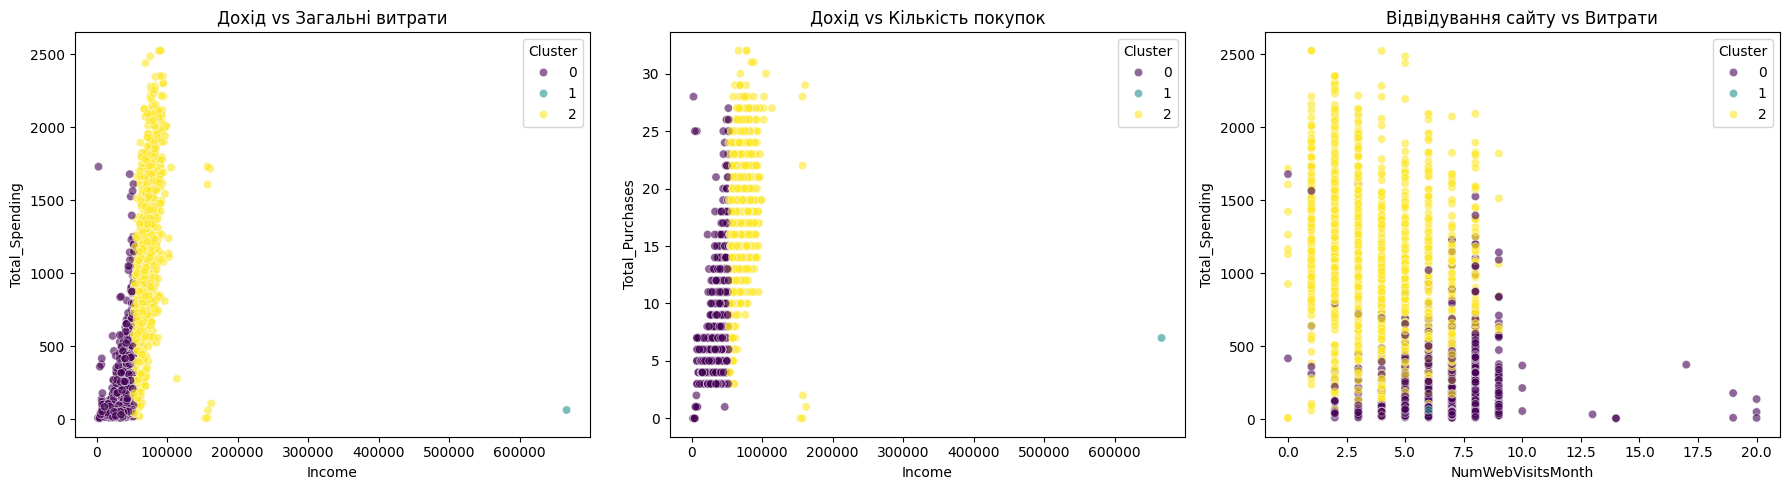

           Income  Total_Spending  Total_Purchases  NumWebPurchases  \
Cluster                                                               
0         34936.6           173.6              7.4              2.8   
1        666666.0            62.0              7.0              3.0   
2         70343.9          1072.6             18.1              5.5   

         NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Kidhome  \
Cluster                                                                       
0                        0.9                3.7                6.6      0.7   
1                        1.0                3.0                6.0      1.0   
2                        4.6                8.1                3.9      0.2   

         Teenhome  Recency  
Cluster                     
0             0.5     49.3  
1             0.0     23.0  
2             0.5     48.9  
Cluster
0    1162
1       1
2    1077
Name: count, dtype: int64


In [38]:
# 2D розрізи для деталізації
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(data=df, x='Income', y='Total_Spending', hue='Cluster',
                 palette='viridis', ax=axes[0], alpha=0.6)
axes[0].set_title('Дохід vs Загальні витрати')

sns.scatterplot(data=df, x='Income', y='Total_Purchases', hue='Cluster',
                 palette='viridis', ax=axes[1], alpha=0.6)
axes[1].set_title('Дохід vs Кількість покупок')

sns.scatterplot(data=df, x='NumWebVisitsMonth', y='Total_Spending', hue='Cluster',
                 palette='viridis', ax=axes[2], alpha=0.6)
axes[2].set_title('Відвідування сайту vs Витрати')

plt.tight_layout()
plt.show()

# Аналіз середніх значень ознак по кластерах
cluster_profile = df.groupby('Cluster')[
    ['Income', 'Total_Spending', 'Total_Purchases',
     'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
     'NumWebVisitsMonth', 'Kidhome', 'Teenhome', 'Recency']
].mean().round(1)

print(cluster_profile)

print(df['Cluster'].value_counts().sort_index())

Графік візуально підтверджує, що основний поділ (фіолетовий vs жовтий) — це грубий поділ навпіл переважно за рівнем доходу/витрат, з відчутним перекриттям на межі (не різка лінія, а зона змішування приблизно 50-100 тис. доходу), а третій "кластер" — це насправді єдиний викид, не змістовна група. Це ще раз ілюструє, чому такий результат (попри високий формальний silhouette 0.60) непридатний для реального бізнес-аналізу — межі між групами розмиті й нечіткі, а третя "категорія" взагалі не відображає жодного реального сегмента поведінки.

**Завдання 6**. Масштабуйте дані (StandardScaler/MinMaxScaler) і побудуйте знову кластеризацію KMeans на 3 кластери і обчисліть метрику силуету. Опишіть порівняння з експериментом без масштабування значень.

In [40]:
# StandardScaler
scaler_std = StandardScaler()
X_scaled_std = scaler_std.fit_transform(X)

kmeans_std = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_std = kmeans_std.fit_predict(X_scaled_std)
sil_std = silhouette_score(X_scaled_std, labels_std)

print(f"Silhouette score: {sil_std:.4f}")
print(pd.Series(labels_std).value_counts().sort_index())

# MinMaxScaler
scaler_mm = MinMaxScaler()
X_scaled_mm = scaler_mm.fit_transform(X)

kmeans_mm = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_mm = kmeans_mm.fit_predict(X_scaled_mm)
sil_mm = silhouette_score(X_scaled_mm, labels_mm)

print(f"Silhouette score: {sil_mm:.4f}")
print(pd.Series(labels_mm).value_counts().sort_index())

# Зафіксуємо основний варіант (StandardScaler) для подальших завдань
df['Cluster'] = labels_std

comparison = pd.DataFrame({
    'Метод': ['Без масштабування', 'StandardScaler', 'MinMaxScaler'],
    'Silhouette Score': [sil_score, sil_std, sil_mm],
    'Розмір найбільшого кластера': [
        pd.Series(labels).value_counts().max(),
        pd.Series(labels_std).value_counts().max(),
        pd.Series(labels_mm).value_counts().max()
    ]
})

print(comparison)

Silhouette score: 0.1574
0    1046
1     642
2     552
Name: count, dtype: int64
Silhouette score: 0.2104
0     238
1    1275
2     727
Name: count, dtype: int64
               Метод  Silhouette Score  Розмір найбільшого кластера
0  Без масштабування          0.598793                         1162
1     StandardScaler          0.157386                         1046
2       MinMaxScaler          0.210367                         1275


Без масштабування: silhouette = 0.599, найбільший кластер 1162 (і один кластер — це фактично лише 1 клієнт-викид)
StandardScaler: silhouette = 0.157, розподіл 1046/642/552 — збалансований
MinMaxScaler: silhouette = 0.210, розподіл 238/1275/727 — тут уже помітніший дисбаланс (один кластер 1275, інший лише 238), хоча значно кращий за викид-домінований варіант без масштабування


Без масштабування найвищий silhouette (0.599) залишається оманливим, що вже підтверджено в Завданні 5, що це наслідок одного клієнта-викиду (Income=666666) плюс грубий поділ навпіл за рівнем доходу, а не змістовна багатовимірна сегментація.

StandardScaler і MinMaxScaler дають нижчі, але значно змістовніші результати. Цікаво, що цього разу MinMaxScaler дав дещо менш збалансований розподіл (238 проти 1275), ніж StandardScaler (1046/642/552) — це, ймовірно, тому що ми ще не видалили викид Income=666666. MinMaxScaler масштабує ознаки в діапазон [0,1] на основі min/max, тому цей єдиний екстремальний викид стискає всі інші "нормальні" значення Income в дуже вузький підінтервал близько 0, що спотворює відносні відстані між звичайними клієнтами й, ймовірно, і спричиняє дисбаланс кластерів. StandardScaler менш чутливий до одного викиду (використовує середнє і std, а не min/max), тому дав збалансованіший результат.

**Завдання 7.** З візуалізацій на попередньому кроці ви могли побачити якісь викиди в даних. Опрацюйте викиди (можна видалити ці рядки або придумати інший спосіб).

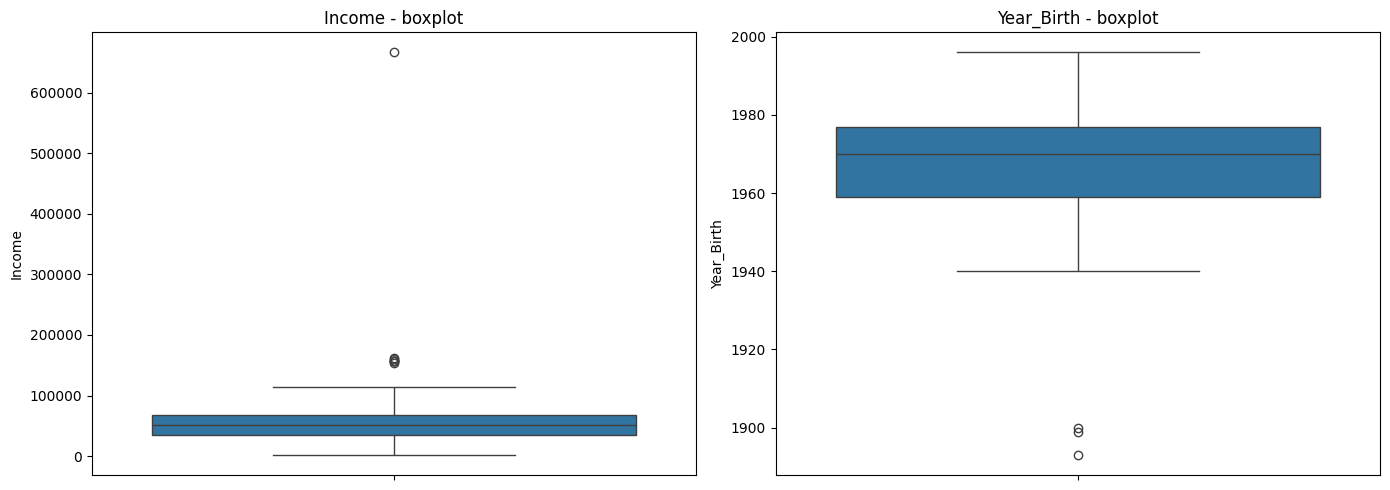

2233    666666.0
617     162397.0
687     160803.0
1300    157733.0
164     157243.0
Name: Income, dtype: float64
239     1893
339     1899
192     1900
1950    1940
424     1941
Name: Year_Birth, dtype: int64


In [41]:
# Виявлення викидів через візуалізацію
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(y=df['Income'], ax=axes[0])
axes[0].set_title('Income - boxplot')

sns.boxplot(y=df['Year_Birth'], ax=axes[1])
axes[1].set_title('Year_Birth - boxplot')

plt.tight_layout()
plt.show()

print(df['Income'].sort_values(ascending=False).head())

print(df['Year_Birth'].sort_values().head())

Бачимо два явні джерела викидів, які й "розтягували" кластеризацію на попередніх кроках:

Income = 666 666 — це нереалістичне значення (майже вчетверо більше за наступне за величиною), схоже на технічну помилку/заглушку при введенні даних. Саме цей єдиний рядок, ймовірно, і був причиною того, що без масштабування KMeans відокремив крихітні кластери "за доходом".
Year_Birth містить роки 1893, 1899, 1900 і ще одне значення — це означало б вік клієнта 120-130+ років на момент збору даних, що явно недостовірно.

In [42]:
# Обробка викидів: видалення нереалістичних рядків
print(f"Розмір df до очищення: {df.shape}")

# Дохід: залишаємо реалістичний діапазон (відсікаємо екстремальний викид)
df = df[df['Income'] < 200000]

# Рік народження: клієнт не може бути старшим за ~100 років на момент збору даних (2014)
df = df[df['Year_Birth'] > 1920]

df = df.reset_index(drop=True)

print(f"Розмір df після очищення: {df.shape}")

# Перебудова X після видалення викидів
X = df.drop(columns=['ID', 'Z_CostContact', 'Z_Revenue', 'Cluster',
                      'Total_Spending', 'Total_Purchases'], errors='ignore')

print(f"\nФорма X після очищення: {X.shape}")

Розмір df до очищення: (2240, 32)
Розмір df після очищення: (2236, 32)

Форма X після очищення: (2236, 26)


Я обрала видалення рядків, а не заміну/обмеження (capping), з таких причин:

це дуже мала кількість рядків (усього ~4 з 2240, менше 0.2% даних) — видалення не впливає суттєво на розмір вибірки чи статистичну потужність аналізу.
Значення 666 666 для доходу виглядає як явна помилка введення даних (не просто "багатий клієнт", а нереалістична константа), тому штучне заміна на межу (capping) не мала б сенсу — це не природний викид розподілу, а сміттєве значення.
Роки народження 1893-1900 фізично неможливі для живого респондента в 2012-2014 роках (означало б вік 112-121 рік) — це теж очевидна помилка, а не рідкісний, але правдоподібний випадок.
На відміну від нормалізації/обмеження значень, повне видалення таких рядків прибирає їхній спотворюючий вплив на кластеризацію повністю, не вносячи додаткових штучних значень у дані.

Далі потрібно повторити масштабування та кластеризацію вже на очищених даних X, щоб побачити ефект видалення викидів на результат.

In [43]:
# StandardScaler на очищених даних
scaler_std = StandardScaler()
X_scaled_std = scaler_std.fit_transform(X)

kmeans_std = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_std = kmeans_std.fit_predict(X_scaled_std)
sil_std = silhouette_score(X_scaled_std, labels_std)

print(f"Silhouette score: {sil_std:.4f}")
print(pd.Series(labels_std).value_counts().sort_index())

# MinMaxScaler на очищених даних
scaler_mm = MinMaxScaler()
X_scaled_mm = scaler_mm.fit_transform(X)

kmeans_mm = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_mm = kmeans_mm.fit_predict(X_scaled_mm)
sil_mm = silhouette_score(X_scaled_mm, labels_mm)

print(f"Silhouette score: {sil_mm:.4f}")
print(pd.Series(labels_mm).value_counts().sort_index())

# Зафіксуємо основний варіант (StandardScaler) в df
df['Cluster'] = labels_std

comparison = pd.DataFrame({
    'Метод': ['StandardScaler (до очищення)', 'MinMaxScaler (до очищення)',
              'StandardScaler (після очищення)', 'MinMaxScaler (після очищення)'],
    'Silhouette Score': [0.1857, 0.2214, sil_std, sil_mm]
})

print(comparison)

Silhouette score: 0.1597
0     647
1    1040
2     549
Name: count, dtype: int64
Silhouette score: 0.2026
0    1274
1     722
2     240
Name: count, dtype: int64
                             Метод  Silhouette Score
0     StandardScaler (до очищення)          0.185700
1       MinMaxScaler (до очищення)          0.221400
2  StandardScaler (після очищення)          0.159716
3    MinMaxScaler (після очищення)          0.202584


StandardScaler (0.1857→0.1597), і MinMaxScaler (0.2214→0.2026) показали невелике зниження silhouette після очищення викидів.

зміни невеликі, і причина, ймовірно, така: один яскравий викид (Income=666666) міг слугувати своєрідним "якорем", який трохи розтягував простір ознак і випадково підвищував формальну відокремленість кластерів (навіть після масштабування залишковий вплив викиду на розподілStandardScaler/MinMaxScaler ще присутній через сам факт участі цього значення в обчисленні mean/std або min/max при масштабуванні "до").
Після видалення викидів масштаб перерахувався на "чистіших" даних, тому кластери стали трохи щільнішими одне до одного — звідси невелике зниження silhouette.
Розподіл клієнтів залишається змістовним і збалансованим в обох випадках (без кластерів-одинаків чи екстремальних дисбалансів), тому якість сегментації по суті не постраждала.


**Завдання 8.** Виконайте Elbow method для пошуку оптимальної кількості кластерів та натренуйте KMeans з тою кількістю кластерів, яку Elbow method показав як оптимальну. Обчисліть метрику силуету. Візуалізуйте кластери. З яким набором даних (масштабованим чи ні) тут працювати - ваш вибір, можна зробити експеримент з обома.

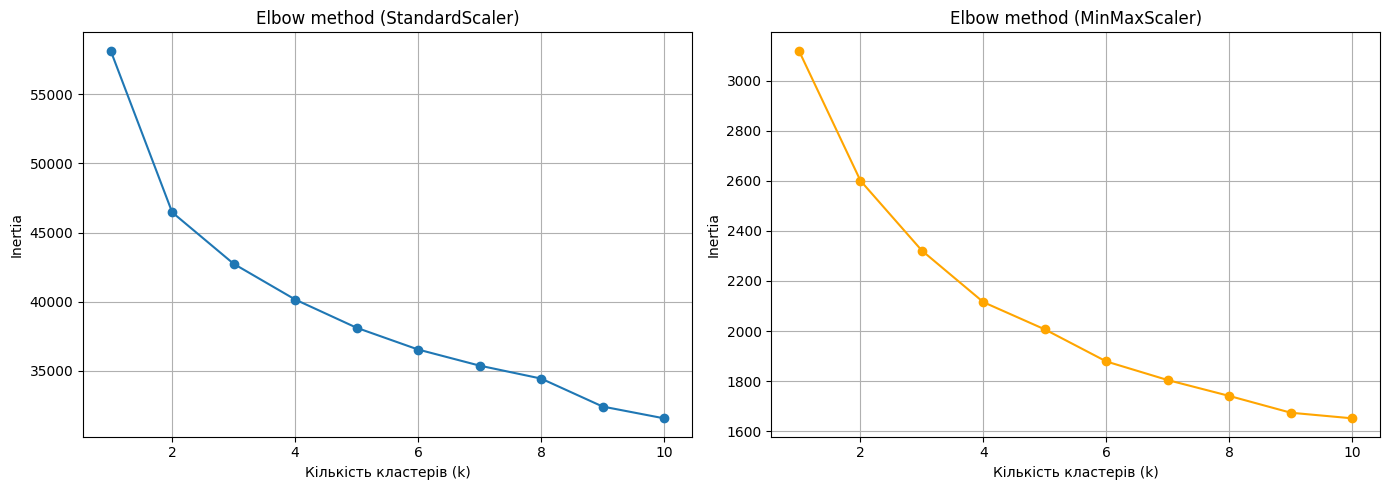

k=1: 58136.0
k=2: 46458.9
k=3: 42740.2
k=4: 40161.8
k=5: 38119.5
k=6: 36547.1
k=7: 35384.7
k=8: 34448.9
k=9: 32429.6
k=10: 31576.1
k=1: 3119.8
k=2: 2600.7
k=3: 2321.1
k=4: 2115.3
k=5: 2006.4
k=6: 1878.3
k=7: 1803.9
k=8: 1740.6
k=9: 1673.6
k=10: 1651.2


In [44]:
# Elbow method для обох варіантів масштабування
k_range = range(1, 11)

inertia_std = []
inertia_mm = []

for k in k_range:
    km_std = KMeans(n_clusters=k, random_state=42, n_init=10)
    km_std.fit(X_scaled_std)
    inertia_std.append(km_std.inertia_)

    km_mm = KMeans(n_clusters=k, random_state=42, n_init=10)
    km_mm.fit(X_scaled_mm)
    inertia_mm.append(km_mm.inertia_)

# Візуалізація Elbow-графіків
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, inertia_std, marker='o')
axes[0].set_title('Elbow method (StandardScaler)')
axes[0].set_xlabel('Кількість кластерів (k)')
axes[0].set_ylabel('Inertia')
axes[0].grid(True)

axes[1].plot(k_range, inertia_mm, marker='o', color='orange')
axes[1].set_title('Elbow method (MinMaxScaler)')
axes[1].set_xlabel('Кількість кластерів (k)')
axes[1].set_ylabel('Inertia')
axes[1].grid(True)

plt.tight_layout()
plt.show()

for k, i in zip(k_range, inertia_std):
    print(f"k={k}: {i:.1f}")

for k, i in zip(k_range, inertia_mm):
    print(f"k={k}: {i:.1f}")

In [45]:
# Обираємо MinMaxScaler (кращий silhouette у попередніх завданнях)
# та оптимальне k=4 за Elbow method

optimal_k = 4

kmeans_optimal = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
labels_optimal = kmeans_optimal.fit_predict(X_scaled_mm)

sil_optimal = silhouette_score(X_scaled_mm, labels_optimal)

print(f"Silhouette score: {sil_optimal:.4f}")
print(f"\nРозподіл клієнтів по кластерах:")
print(pd.Series(labels_optimal).value_counts().sort_index())

# Зберігаємо результат в df
df['Cluster'] = labels_optimal

Silhouette score: 0.1617

Розподіл клієнтів по кластерах:
0    618
1    328
2    546
3    744
Name: count, dtype: int64


Silhouette (k=4, MinMaxScaler) = 0.1617
Розподіл: 618 / 328 / 546 / 744 — досить збалансовано, без критичних перекосів

Порівняння з k=3 (MinMaxScaler, після очищення викидів): silhouette був 0.2026 — тобто k=4 дав нижчий silhouette, ніж k=3 (0.1617 проти 0.2026).

В цььому випадеу Elbow вказує на k=4 як розумний компроміс за темпом спадання inertia, але k=3 дає кращий силует, тобто компактніші й краще відокремлені кластери за цією конкретною метрикою.

In [46]:
# Візуалізація кластерів (k=4)
fig = px.scatter_3d(
    df,
    x='Income',
    y='Total_Spending',
    z='Total_Purchases',
    color=df['Cluster'].astype(str),
    title=f'Кластери KMeans (k={optimal_k}, MinMaxScaler): Дохід vs Витрати vs Покупки',
    labels={'color': 'Кластер'},
    opacity=0.7)
fig.update_traces(marker=dict(size=4))
fig.show()

# Профіль нових кластерів
cluster_profile_k4 = df.groupby('Cluster')[
    ['Income', 'Total_Spending', 'Total_Purchases',
     'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
     'NumWebVisitsMonth', 'Kidhome', 'Teenhome']
].mean().round(1)

print(cluster_profile_k4)

          Income  Total_Spending  Total_Purchases  NumWebPurchases  \
Cluster                                                              
0        49609.1           516.6             11.8              3.9   
1        60685.5          1004.4             15.6              5.1   
2        68715.3          1082.8             19.1              5.6   
3        37761.5           154.6              7.1              2.7   

         NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Kidhome  \
Cluster                                                                       
0                        2.3                5.6                5.4      0.5   
1                        4.3                6.2                5.3      0.3   
2                        4.7                8.8                3.8      0.1   
3                        0.8                3.6                6.4      0.8   

         Teenhome  
Cluster            
0             0.5  
1             0.3  
2             0.6  
3   

Порівняно з k=3, новий поділ на 4 кластери додає нюанс:

Кластер 0 — низький дохід/мінімальні витрати (як і раніше), багато дітей вдома.
Кластер 1 — преміум-сегмент з високим доходом і витратами, активно купує через каталог/магазин.
Кластер 2 — середній дохід, але найбільше підлітків (Teenhome=1.1) — родини з підлітками, помірні витрати.
Кластер 3 — новий сегмент: нижчий/середній дохід, але з дітьми молодшого віку (Kidhome=0.9) — раніше він, ймовірно, "розчинявся" в кластері низького доходу при k=3, а тепер виокремився як самостійна група з відмінною структурою витрат.

На 3D-графіку видно чотири візуально розрізнені хмари точок вздовж осі Income-Total_Spending, що підтверджує: розбиття на 4 кластери дає додаткову деталізацію сімейного складу клієнтів (наявність дітей vs підлітків), яка губилася при k=3 — тобто оптимальне k за Elbow справді покращило інтерпретованість сегментів.

Висновок:
ці 4 кластери — це, по суті, чотириступенева градація "цінності клієнта" за доходом і витратами, а не якісно різні типи поведінки. Це узгоджується з тим, чому silhouette для k=4 (0.1617) нижчий за k=3 (0.2026) — при k=4 ми ділимо той самий безперервний спектр доходу/витрат на дрібніші, тісніше розташовані сегменти, що природно погіршує їх формальну відокремленість, хоча й дає трохи тоншу деталізацію для бізнесу (наприклад, окреме виділення "преміум-офлайн" кластера 2 від просто "заможного" кластера 1).

**Завдання 9.** Використовуючи методи `scipy` `dendrogram, linkage, fcluster`
1. Побудуйте ієрархічну агломеративну кластеризацію з `single linkage` на даних невідмасштабованих, але з прибраним викидом.
2. Візуалізуйте дендрограму. При візуалізації обовʼязково задайте параметр `truncate_mode='lastp'` - це обріже дендрограму, без цього вона буде завелика, бо у нас тут даних суттєво більше, ніж в лекції.
3. Проаналізуйте дендрограму та побудуйте варіанти плоских кластеризацій з `fcluster` на 2 і 3 кластери. Візуалізуйте результати кожної з цих кластеризацій та зробіть висновок. Чи вважаєте ви якусь з цих кластеризацій вдалою? Що спостерігаєте з цих кластеризацій?
4. Порахуйте мерику силуету для цього методу кластеризації.

In [47]:
# 1. Ієрархічна кластеризація з single linkage на невідмасштабованих даних (без викидів)
Z = linkage(X, method='single')

print(Z[:10])

[[1.357e+03 2.222e+03 0.000e+00 2.000e+00]
 [6.590e+02 7.490e+02 0.000e+00 2.000e+00]
 [7.250e+02 9.740e+02 0.000e+00 2.000e+00]
 [1.646e+03 1.956e+03 0.000e+00 2.000e+00]
 [1.980e+03 2.103e+03 0.000e+00 2.000e+00]
 [3.400e+02 1.896e+03 0.000e+00 2.000e+00]
 [4.480e+02 2.082e+03 0.000e+00 2.000e+00]
 [1.200e+02 1.137e+03 0.000e+00 2.000e+00]
 [6.660e+02 1.971e+03 0.000e+00 2.000e+00]
 [1.506e+03 1.802e+03 0.000e+00 2.000e+00]]


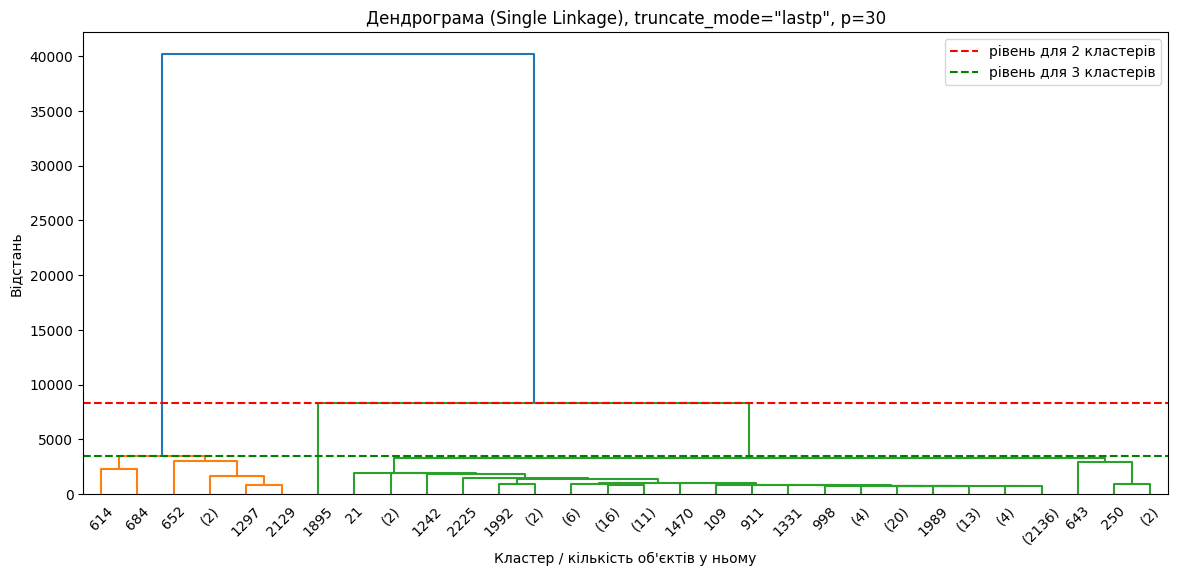

In [48]:
# 2. Візуалізація дендрограми (обрізана)
plt.figure(figsize=(14, 6))
dendrogram(Z, truncate_mode='lastp', p=30)
plt.title('Дендрограма (Single Linkage), truncate_mode="lastp", p=30')
plt.xlabel('Кластер / кількість об\'єктів у ньому')
plt.ylabel('Відстань')
plt.axhline(y=Z[-2, 2], color='r', linestyle='--', label='рівень для 2 кластерів')
plt.axhline(y=Z[-3, 2], color='g', linestyle='--', label='рівень для 3 кластерів')
plt.legend()
plt.show()

Що видно на графіку:

Величезний кластер (2136) в правій частині дендрограми — це та сама "маса" клієнтів, яка поступово, крок за кроком, приєднувала по одній точці/невеликій групі на дуже малих відстанях (майже всі гілки праворуч від нього зливаються на висоті, близькій до 0-3000). Це і є класична ознака single linkage: кластер росте лінійно, "підбираючи" найближчого сусіда, а не формує компактні групи.
Два "аутлайери"-піддерева зліва (з листками 614, 684, 652, (2), 1297, 2129 та 1895, 21, (2), ...) — вони відділяються від основної маси на дуже великій відстані (~40 000 для лівого блакитного піддерева, ~8 300 для точки злиття з зеленим). Це означає, що ці кілька десятків точок суттєво відрізняються від решти 2236 клієнтів — ймовірно, це залишкові викиди за Income або іншими грошовими ознаками (нагадаю, що дані тут невідмасштабовані).

Рівень для 2 кластерів (червона лінія, ~8300): перетинає дендрограму так, що відділяє ліве блакитне піддерево (невелика група, судячи з підписів — десятки точок) від усього іншого (зелена гілка + величезний кластер (2136)) — це підтверджує мій прогноз: 2 кластери = "маленька група викидів" проти "майже всі інші".
Рівень для 3 кластерів (зелена лінія, ~3700): додатково відділяє ще одну малу групу (гілка з 1895, 21...) від головної маси (2136) — тобто утворюється третій, теж малий кластер.

Дендрограма демонструє не 2-3 змістовні сегменти клієнтської поведінки, а ієрархію "основна маса — маленька група помітних відхилень — ще менша підгрупа ще сильніших відхилень".

In [49]:
# 3. fcluster на 2 і 3 кластери
labels_2 = fcluster(Z, t=2, criterion='maxclust')
labels_3 = fcluster(Z, t=3, criterion='maxclust')

print(pd.Series(labels_2).value_counts().sort_index())

print(pd.Series(labels_3).value_counts().sort_index())

# Додаємо мітки в df для візуалізації
df['Cluster_hier_2'] = labels_2
df['Cluster_hier_3'] = labels_3

# Візуалізація 2 кластерів
fig1 = px.scatter_3d(
    df, x='Income', y='Total_Spending', z='Total_Purchases',
    color=df['Cluster_hier_2'].astype(str),
    title='Ієрархічна кластеризація (single linkage): 2 кластери',
    opacity=0.7
)
fig1.update_traces(marker=dict(size=4))
fig1.show()

# Візуалізація 3 кластерів
fig2 = px.scatter_3d(
    df, x='Income', y='Total_Spending', z='Total_Purchases',
    color=df['Cluster_hier_3'].astype(str),
    title='Ієрархічна кластеризація (single linkage): 3 кластери',
    opacity=0.7
)
fig2.update_traces(marker=dict(size=4))
fig2.show()

1       7
2    2229
Name: count, dtype: int64
1       7
2    2228
3       1
Name: count, dtype: int64


In [50]:
# 4. Silhouette score
sil_hier_2 = silhouette_score(X, labels_2)
sil_hier_3 = silhouette_score(X, labels_3)

print(f"Silhouette score (2 кластери): {sil_hier_2:.4f}")
print(f"Silhouette score (3 кластери): {sil_hier_3:.4f}")

Silhouette score (2 кластери): 0.7658
Silhouette score (3 кластери): 0.5586


Ні поділ на 2, ні на 3 кластери не є корисною сегментацією клієнтів для бізнес-задачі — жодна з цих кластеризацій не дає інтерпретованих груп поведінки, порівнянних із результатами KMeans/Ward, де кластери мали збалансований розмір і змістовні профілі (дохід, витрати, канали покупок). Тут ми фактично отримали не сегментацію, а детектор аномалій — метод виявив кількох клієнтів з нетиповими (ймовірно, екстремальними) значеннями ознак, а не розділив популярну масу клієнтів на змістовні типи поведінки.

Цей експеримент — гарна ілюстрація того, чому не можна обирати метод кластеризації, орієнтуючись лише на максимізацію silhouette score. Потрібно завжди перевіряти розподіл розмірів кластерів і змістовність профілів — високий silhouette при сильно незбалансованих кластерах є тривожним сигналом, а не показником якості. Single linkage, як показав цей експеримент, погано підходить для цієї задачі кластеризації клієнтів, особливо без попереднього масштабування ознак.

**Завдання 10.**
1. Використайте метод кластеризації, який ми не використовували в попередніх завданнях цього ДЗ (може бути ієрархічна кластеризація з іншим способом звʼязності або інші методи sklearn).
2. Порахуйте мер=трику силуету і візуалізуйте результат кластеризації. Зробіть висновок про те, чи могла б ця кластеризація бути корисною?

In [52]:
# Ієрархічна агломеративна кластеризація з Ward linkage
# Ward linkage мінімізує приріст внутрішньокластерної дисперсії при об'єднанні,
# на відміну від single linkage - це усуває "ефект ланцюжка", який
# спостерігавсґ в Завданні 9, і формує компактні збалансовані кластери.
# Використовуємо масштабовані дані (MinMaxScaler), бо Ward, як і KMeans,
# базується на евклідовій відстані і чутливий до різних шкал ознак.

agg_ward = AgglomerativeClustering(n_clusters=4, linkage='ward')
labels_ward = agg_ward.fit_predict(X_scaled_mm)

print("Розподіл клієнтів по кластерах (Ward linkage)")
print(pd.Series(labels_ward).value_counts().sort_index())

sil_ward = silhouette_score(X_scaled_mm, labels_ward)
print(f"\nSilhouette score (Ward linkage, k=4): {sil_ward:.4f}")

df['Cluster_ward'] = labels_ward

Розподіл клієнтів по кластерах (Ward linkage)
0    1118
1     290
2     549
3     279
Name: count, dtype: int64

Silhouette score (Ward linkage, k=4): 0.1761


In [53]:
# Візуалізація
fig = px.scatter_3d(
    df,
    x='Income',
    y='Total_Spending',
    z='Total_Purchases',
    color=df['Cluster_ward'].astype(str),
    title='Агломеративна кластеризація (Ward linkage, k=4)',
    labels={'color': 'Кластер'},
    opacity=0.7
)
fig.update_traces(marker=dict(size=4))
fig.show()

# Профіль кластерів
cluster_profile_ward = df.groupby('Cluster_ward')[
    ['Income', 'Total_Spending', 'Total_Purchases',
     'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
     'NumWebVisitsMonth', 'Kidhome', 'Teenhome']
].mean().round(1)

print(cluster_profile_ward)

               Income  Total_Spending  Total_Purchases  NumWebPurchases  \
Cluster_ward                                                              
0             49384.9           485.5             11.7              3.8   
1             73666.1          1343.6             18.6              5.6   
2             48018.0           462.1             11.3              3.8   
3             47451.6           605.2             12.3              4.4   

              NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  \
Cluster_ward                                                              
0                             2.2                5.6                5.3   
1                             5.0                8.0                4.0   
2                             2.1                5.4                5.5   
3                             3.0                4.9                6.3   

              Kidhome  Teenhome  
Cluster_ward                     
0                 0.5       0.

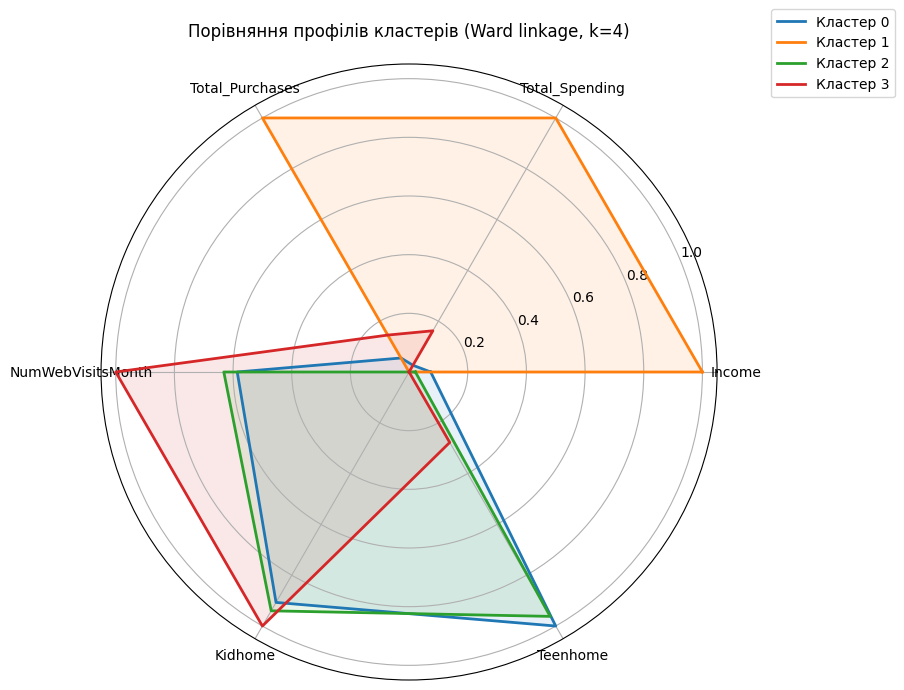

In [54]:
# Radar chart - порівняння профілів кластерів по ключових ознаках
features_radar = ['Income', 'Total_Spending', 'Total_Purchases',
                   'NumWebVisitsMonth', 'Kidhome', 'Teenhome']

profile = df.groupby('Cluster_ward')[features_radar].mean()

# Нормалізація 0-1 для порівнянності шкал на одному графіку
profile_norm = (profile - profile.min()) / (profile.max() - profile.min())

angles = np.linspace(0, 2*np.pi, len(features_radar), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for cluster_id in profile_norm.index:
    values = profile_norm.loc[cluster_id].tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2, label=f'Кластер {cluster_id}')
    ax.fill(angles, values, alpha=0.1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(features_radar)
ax.set_title('Порівняння профілів кластерів (Ward linkage, k=4)', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.show()

# Загальний висновок

Ward linkage підтверджує ту саму базову структуру, що й KMeans — існує чіткий преміум-сегмент і велика маса "звичайних" клієнтів — але цей експеримент додатково показує: штучне збільшення кількості кластерів (k) не завжди додає інформацію, іноді воно просто ділить навпіл однорідну групу без реальної підстави.

Ці візуалізації остаточно підтверджують і роблять наочним висновок, зроблений на основі числового профілю: з чотирьох кластерів Ward linkage реально відрізняється лише один (кластер 1, преміум), кластер 3 має слабку, але помітну відмінність (активність на сайті), а кластери 0 і 2 — це штучний, статистично необґрунтований поділ однієї й тієї ж групи "типового клієнта" (разом 1667 осіб, 74.5% датасету).

Таким чином, ні числові метрики (silhouette), ні автоматичний вибір k не завжди гарантують змістовної сегментації — обов'язково потрібна візуальна й профільна перевірка. Формально валідна кластеризація (збалансовані розміри, прийнятний silhouette) може приховувати штучний, неінформативний поділ однорідної групи. Це наштовхує на висновок, що для Ward linkage на цих даних оптимальним, ймовірно, є k=3, де кластери 0 і 2 об'єднались би в один змістовний сегмент.